In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [4]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

print("Visualization settings applied.")

Visualization settings applied.


In [5]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.to_csv("titanic.csv", index=False)

print("Offline copy saved as titanic.csv")

Offline copy saved as titanic.csv


In [8]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(891, 15)


In [9]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [10]:
print("Statistical Summary")

display(df.describe())

Statistical Summary


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
display(
    df.describe(include="object")
)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [12]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [13]:
missing_values = df.isnull().sum()

display(
    missing_values
)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
missing_percent = (
    df.isnull().mean() * 100
).round(2)

missing_percent = (
    missing_percent[
        missing_percent > 0
    ]
)

missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_report = (
    missing_report[
        missing_report["Missing Values"] > 0
    ]
)

display(missing_report)

,Missing Values,Missing Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [15]:
missing_report.to_csv(
    "outputs/missing_value_report.csv",
    index=True
)

print(
    "Missing value report saved!"
)

Missing value report saved!


In [16]:
clean_df = df.copy()

print(
    "Working copy created."
)

Working copy created.


In [17]:
for column in missing_report.index:

    percentage = (
        missing_report.loc[
            column,
            "Missing Percentage"
        ]
    )

    print(
        f"{column} : {percentage}% missing"
    )

age : 19.87% missing
embarked : 0.22% missing
deck : 77.22% missing
embark_town : 0.22% missing


In [18]:
for column in missing_report.index:

    percentage = (
        missing_report.loc[
            column,
            "Missing Percentage"
        ]
    )

    if percentage < 5:

        strategy = "Drop rows"

    elif percentage <= 30:

        strategy = "Impute"

    else:

        strategy = "Drop column"

    print(
        f"{column} --> {strategy}"
    )

age --> Impute
embarked --> Drop rows
deck --> Drop column
embark_town --> Drop rows


In [19]:
rows_before = len(clean_df)

clean_df = clean_df.dropna(
    subset=["embarked", "embark_town"]
)

rows_after = len(clean_df)

print(
    "Rows removed:",
    rows_before - rows_after
)

Rows removed: 2


In [20]:
age_median = clean_df["age"].median()

clean_df["age"] = (
    clean_df["age"]
    .fillna(age_median)
)

print(
    "Age imputed using median."
)

Age imputed using median.


In [21]:
clean_df = clean_df.drop(
    columns=["deck"]
)

print(
    "Deck column dropped."
)

Deck column dropped.


In [22]:
remaining_missing = (
    clean_df.isnull().sum()
)

display(
    remaining_missing[
        remaining_missing > 0
    ]
)

Series([], dtype: int64)

In [23]:
print(
    "Original Shape:",
    df.shape
)

print(
    "Cleaned Shape:",
    clean_df.shape
)

Original Shape: (891, 15)
Cleaned Shape: (889, 14)


In [24]:
clean_df.to_csv(
    "outputs/cleaned_titanic.csv",
    index=False
)

print(
    "Cleaned dataset saved."
)

Cleaned dataset saved.


In [25]:
print("=" * 50)

print("MODULE 2 - PART 1 COMPLETED")

print("=" * 50)

print(
    "Original Rows:",
    len(df)
)

print(
    "Cleaned Rows:",
    len(clean_df)
)

print(
    "Columns:",
    clean_df.columns.tolist()
)

print(
    "\nRemaining Missing Values:"
)

print(
    clean_df.isnull().sum()
)

print("=" * 50)

MODULE 2 - PART 1 COMPLETED
Original Rows: 891
Cleaned Rows: 889
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Remaining Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [26]:
display(clean_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


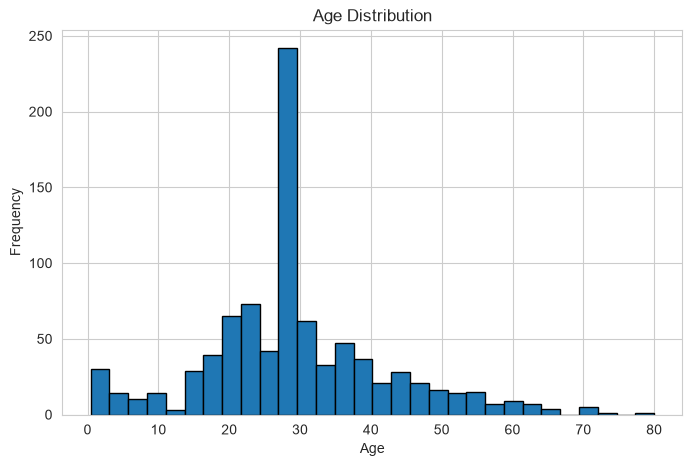

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    clean_df["age"],
    bins=30,
    edgecolor="black"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.savefig("charts/age_histogram.png")

plt.show()

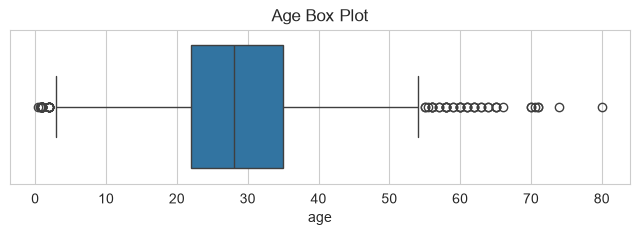

In [28]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["age"]
)

plt.title("Age Box Plot")

plt.savefig("charts/age_boxplot.png")

plt.show()

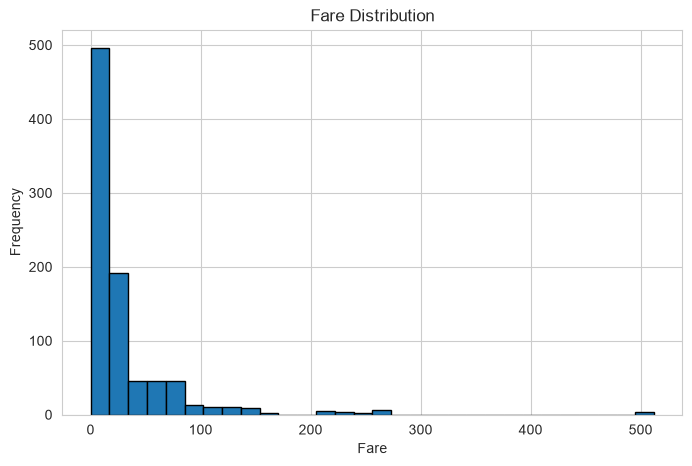

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    clean_df["fare"],
    bins=30,
    edgecolor="black"
)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Frequency")

plt.savefig("charts/fare_histogram.png")

plt.show()

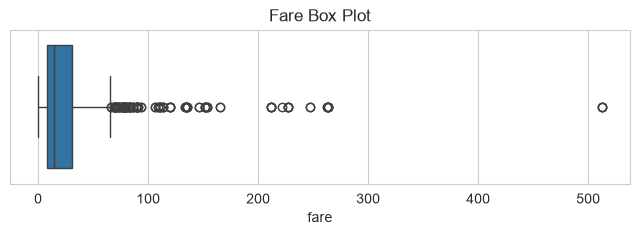

In [30]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=clean_df["fare"]
)

plt.title("Fare Box Plot")

plt.savefig("charts/fare_boxplot.png")

plt.show()

In [31]:
def count_outliers(column):

    Q1 = column.quantile(0.25)

    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = column[
        (column < lower) |
        (column > upper)
    ]

    return len(outliers)

In [32]:
age_outliers = count_outliers(
    clean_df["age"]
)

print(
    "Age Outliers:",
    age_outliers
)

Age Outliers: 65


In [33]:
fare_outliers = count_outliers(
    clean_df["fare"]
)

print(
    "Fare Outliers:",
    fare_outliers
)

Fare Outliers: 114


In [34]:
fare_mean = clean_df["fare"].mean()

fare_median = clean_df["fare"].median()

fare_mode = clean_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)

print("Fare Median:", fare_median)

print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [35]:
if fare_mean > fare_median > fare_mode:

    skew = "Right Skewed"

elif fare_mean < fare_median < fare_mode:

    skew = "Left Skewed"

else:

    skew = "Approximately Symmetric"

print("Fare Distribution:", skew)

Fare Distribution: Right Skewed


In [36]:
survival_by_sex = (
    clean_df
    .groupby("sex")["survived"]
    .mean() * 100
)

display(
    survival_by_sex
)

sex
female    74.038462
male      18.890815
Name: survived, dtype: float64

In [37]:
survival_by_class = (
    clean_df
    .groupby("pclass")["survived"]
    .mean() * 100
)

display(
    survival_by_class
)

pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64

In [38]:
survival_sex_class = (
    clean_df
    .groupby(
        ["sex","pclass"]
    )["survived"]
    .mean() * 100
)

display(
    survival_sex_class
)

sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

In [39]:
corr_df = clean_df[
    [
        "survived",
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare"
    ]
]

In [40]:
corr_matrix = corr_df.corr()

display(
    corr_matrix
)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


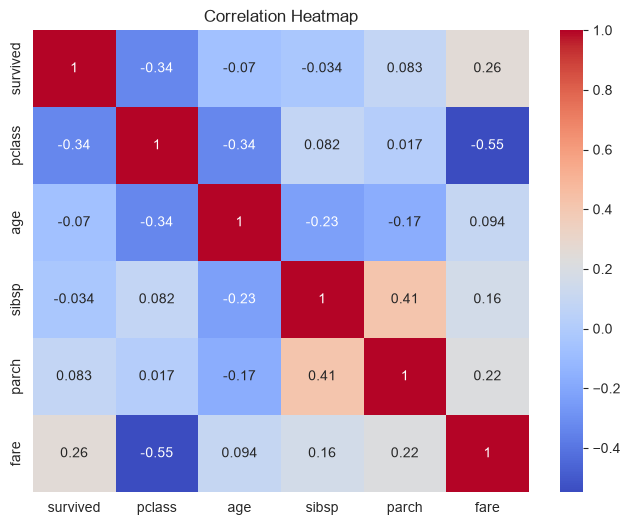

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

In [42]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
)

corr_pairs = corr_pairs[
    corr_pairs < 1
]

corr_pairs = (
    corr_pairs
    .sort_values(
        ascending=False
    )
)

print(
    corr_pairs.head(2)
)

pclass  fare      0.548193
fare    pclass    0.548193
dtype: float64


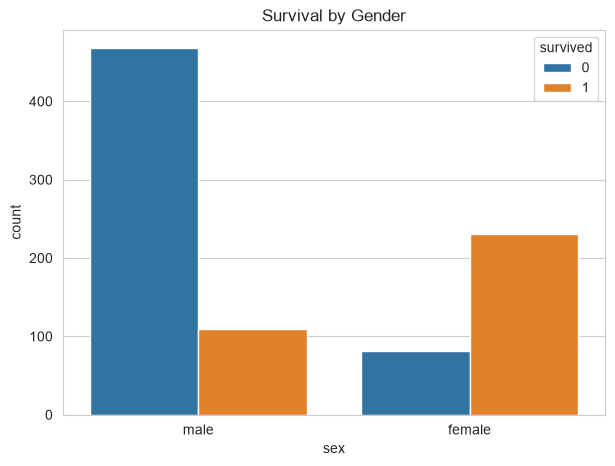

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="sex",
    hue="survived"
)

plt.title(
    "Survival by Gender"
)

plt.savefig(
    "charts/chart1_gender_survival.png"
)

plt.show()

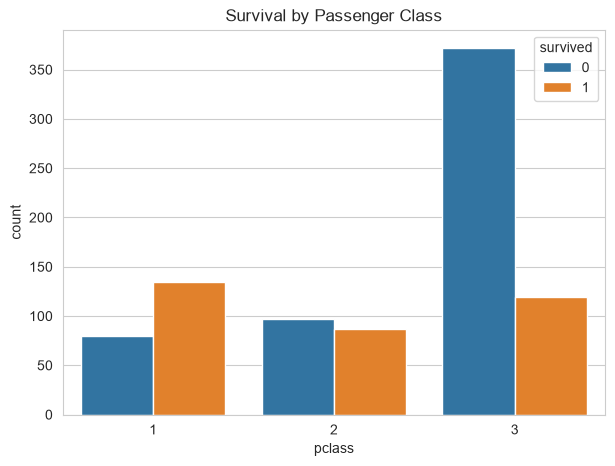

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="pclass",
    hue="survived"
)

plt.title(
    "Survival by Passenger Class"
)

plt.savefig(
    "charts/chart2_class_survival.png"
)

plt.show()

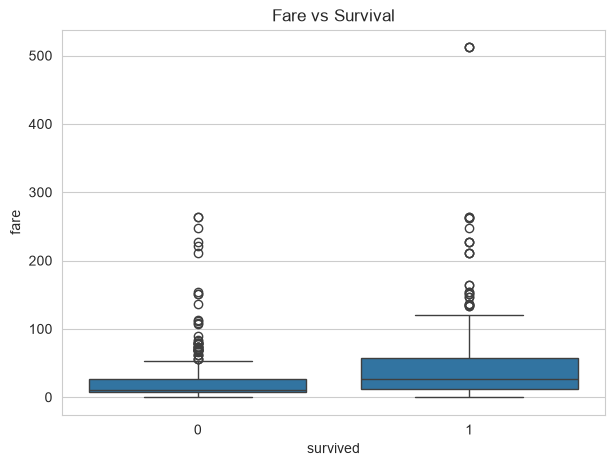

In [45]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="fare"
)

plt.title(
    "Fare vs Survival"
)

plt.savefig(
    "charts/chart3_fare_survival.png"
)

plt.show()

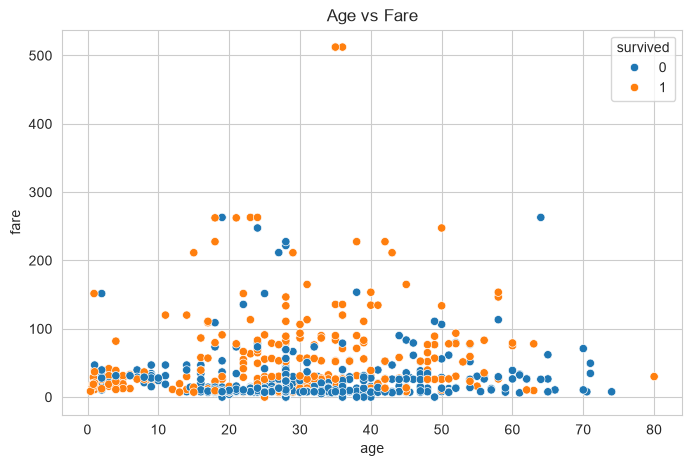

In [46]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title(
    "Age vs Fare"
)

plt.savefig(
    "charts/chart4_age_fare.png"
)

plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [48]:
scaled_df = clean_df.copy()

In [49]:
print("Before Scaling")

display(
    scaled_df[
        [
            "age",
            "fare"
        ]
    ].describe()
)

Before Scaling


,age,fare
count,889.000000,889.000000
mean,29.315152,32.096681
std,12.984932,49.697504
min,0.420000,0.000000
25%,22.000000,7.895800
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


In [50]:
scaled_df[
    [
        "age",
        "fare"
    ]
] = scaler.fit_transform(

    scaled_df[
        [
            "age",
            "fare"
        ]
    ]

)

In [51]:
print("After Scaling")

display(
    scaled_df[
        [
            "age",
            "fare"
        ]
    ].describe()
)

After Scaling


,age,fare
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00


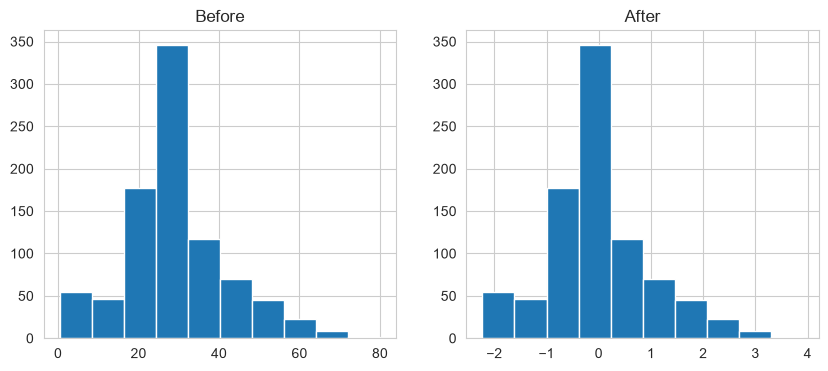

In [52]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(clean_df["age"])

plt.title("Before")

plt.subplot(1,2,2)

plt.hist(scaled_df["age"])

plt.title("After")

plt.savefig(
    "charts/age_scaling.png"
)

plt.show()

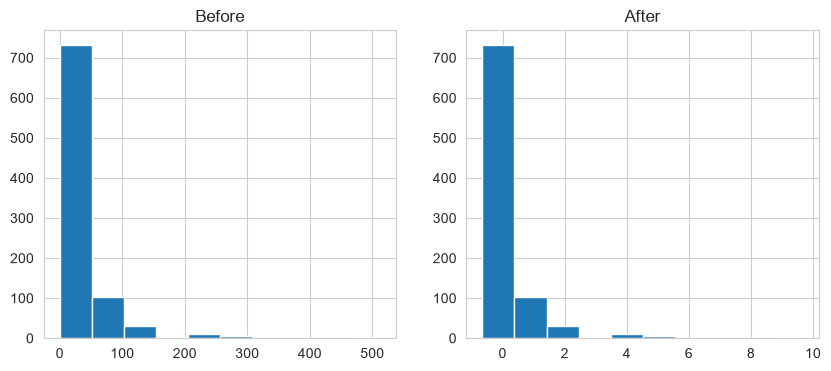

In [53]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(clean_df["fare"])

plt.title("Before")

plt.subplot(1,2,2)

plt.hist(scaled_df["fare"])

plt.title("After")

plt.savefig(
    "charts/fare_scaling.png"
)

plt.show()

In [54]:
scaled_df.to_csv(
    "outputs/scaled_titanic.csv",
    index=False
)

print(
    "Scaled dataset saved."
)

Scaled dataset saved.


In [55]:
print("="*60)

print("MODULE 2 - PART 2 COMPLETED")

print("="*60)

print("Charts Generated:")

print("- Age Histogram")

print("- Age Box Plot")

print("- Fare Histogram")

print("- Fare Box Plot")

print("- Correlation Heatmap")

print("- Survival Charts")

print("- Scaling Comparison")

print()

print("Outputs Generated:")

print("- Missing Report")

print("- Cleaned Titanic")

print("- Scaled Titanic")

print("="*60)

MODULE 2 - PART 2 COMPLETED
Charts Generated:
- Age Histogram
- Age Box Plot
- Fare Histogram
- Fare Box Plot
- Correlation Heatmap
- Survival Charts
- Scaling Comparison

Outputs Generated:
- Missing Report
- Cleaned Titanic
- Scaled Titanic


In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


In [3]:
df = pd.read_csv("titanic.csv")

print("Titanic dataset loaded from CSV.")

display(df.head())

Titanic dataset loaded from CSV.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Dataset Shape:")

print(df.shape)

print("\nMissing Values:")

print(df.isnull().sum())

Dataset Shape:
(891, 15)

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
features = [

    "pclass",

    "sex",

    "age",

    "sibsp",

    "parch",

    "fare",

    "embarked"

]

target = "survived"

X = df[features]

y = df[target]

print("Features Selected:")

print(features)

print("\nTarget:")

print(target)

Features Selected:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target:
survived


Class Distribution
survived
0    549
1    342
Name: count, dtype: int64


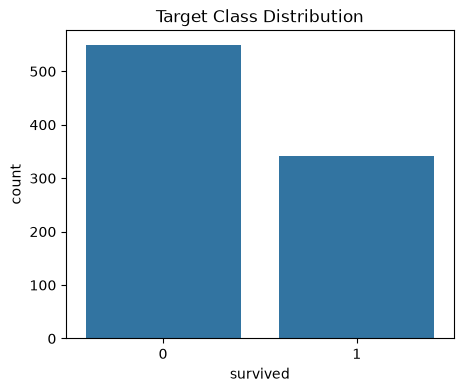

In [6]:
class_counts = y.value_counts()

print("Class Distribution")

print(class_counts)

plt.figure(figsize=(5,4))

sns.countplot(x=y)

plt.title("Target Class Distribution")

plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Training Samples:")

print(len(X_train))

print("\nTesting Samples:")

print(len(X_test))

Training Samples:
712

Testing Samples:
179


In [8]:
numeric_features = [

    "age",

    "fare",

    "sibsp",

    "parch",

    "pclass"

]

categorical_features = [

    "sex",

    "embarked"

]

print("Numeric Features")

print(numeric_features)

print("\nCategorical Features")

print(categorical_features)

Numeric Features
['age', 'fare', 'sibsp', 'parch', 'pclass']

Categorical Features
['sex', 'embarked']


In [9]:
numeric_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(

                strategy="median"

            )

        ),

        (

            "scaler",

            StandardScaler()

        )

    ]

)

print("Numeric pipeline created.")

Numeric pipeline created.


In [10]:
categorical_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(

                strategy="most_frequent"

            )

        ),

        (

            "encoder",

            OneHotEncoder(

                handle_unknown="ignore"

            )

        )

    ]

)

print("Categorical pipeline created.")

Categorical pipeline created.


In [11]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numeric_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

print("ColumnTransformer created.")

ColumnTransformer created.


In [12]:
logistic_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            LogisticRegression(

                random_state=42,

                max_iter=1000

            )

        )

    ]

)

print("Logistic Regression Pipeline Ready.")

Logistic Regression Pipeline Ready.


In [13]:
logistic_pipeline.fit(

    X_train,

    y_train

)

print(

    "Logistic Regression Trained Successfully!"

)

Logistic Regression Trained Successfully!


In [14]:
decision_tree_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            DecisionTreeClassifier(

                random_state=42

            )

        )

    ]

)

print("Decision Tree Pipeline Ready.")

Decision Tree Pipeline Ready.


In [15]:
decision_tree_pipeline.fit(

    X_train,

    y_train

)

print(

    "Decision Tree Trained Successfully!"

)

Decision Tree Trained Successfully!


In [16]:
random_forest_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            RandomForestClassifier(

                random_state=42

            )

        )

    ]

)

print("Random Forest Pipeline Ready.")

Random Forest Pipeline Ready.


In [17]:
random_forest_pipeline.fit(

    X_train,

    y_train

)

print(

    "Random Forest Trained Successfully!"

)

Random Forest Trained Successfully!


In [18]:
logistic_predictions = logistic_pipeline.predict(X_test)

decision_predictions = decision_tree_pipeline.predict(X_test)

random_predictions = random_forest_pipeline.predict(X_test)

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [19]:
prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Logistic": logistic_predictions,

    "Decision Tree": decision_predictions,

    "Random Forest": random_predictions

})

display(

    prediction_df.head(15)

)

,Actual,Logistic,Decision Tree,Random Forest
0,0,0,0,0
1,0,0,0,0
2,1,0,0,0
3,0,0,0,0
4,1,1,1,1
5,1,0,0,0
6,1,1,1,1
7,0,0,1,1
8,0,0,0,0
9,0,0,0,0


In [21]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import plot_tree

In [22]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977


In [23]:
decision_accuracy = accuracy_score(
    y_test,
    decision_predictions
)

decision_precision = precision_score(
    y_test,
    decision_predictions
)

decision_recall = recall_score(
    y_test,
    decision_predictions
)

decision_f1 = f1_score(
    y_test,
    decision_predictions
)

print("Accuracy :", decision_accuracy)
print("Precision:", decision_precision)
print("Recall   :", decision_recall)
print("F1 Score :", decision_f1)

Accuracy : 0.8156424581005587
Precision: 0.7727272727272727
Recall   : 0.7391304347826086
F1 Score : 0.7555555555555555


In [24]:
random_accuracy = accuracy_score(
    y_test,
    random_predictions
)

random_precision = precision_score(
    y_test,
    random_predictions
)

random_recall = recall_score(
    y_test,
    random_predictions
)

random_f1 = f1_score(
    y_test,
    random_predictions
)

print("Accuracy :", random_accuracy)
print("Precision:", random_precision)
print("Recall   :", random_recall)
print("F1 Score :", random_f1)

Accuracy : 0.8156424581005587
Precision: 0.8
Recall   : 0.6956521739130435
F1 Score : 0.7441860465116279


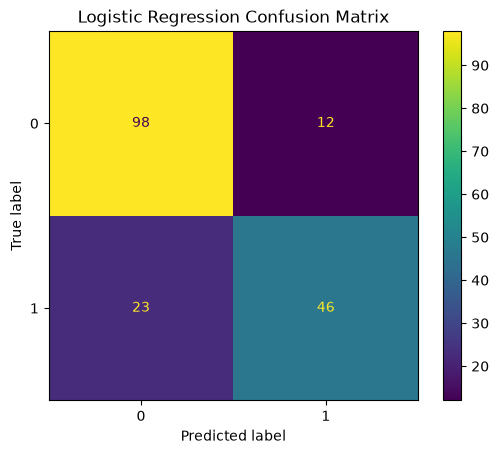

In [25]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.savefig(
    "charts/logistic_confusion_matrix.png"
)

plt.show()

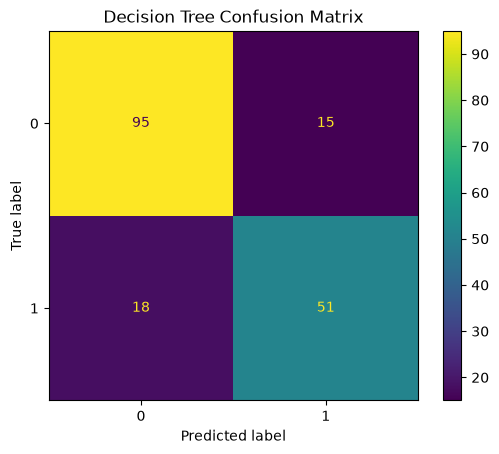

In [26]:
cm = confusion_matrix(
    y_test,
    decision_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.savefig(
    "charts/decision_confusion_matrix.png"
)

plt.show()

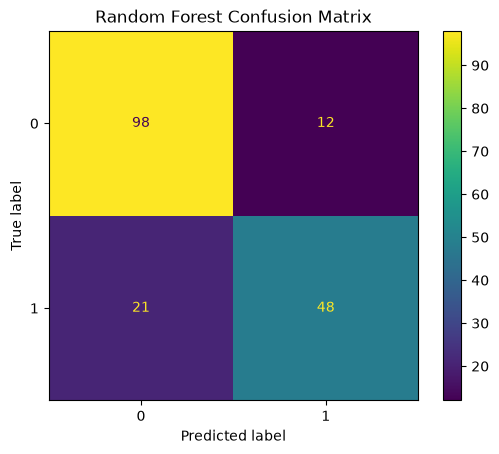

In [27]:
cm = confusion_matrix(
    y_test,
    random_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.savefig(
    "charts/random_confusion_matrix.png"
)

plt.show()

In [28]:
logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:,1]

decision_prob = decision_tree_pipeline.predict_proba(
    X_test
)[:,1]

random_prob = random_forest_pipeline.predict_proba(
    X_test
)[:,1]

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr_log, tpr_log,_ = roc_curve(y_test, logistic_prob)
auc_log = roc_auc_score(y_test, logistic_prob)
print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.8437417654808959


In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr_tree, tpr_tree,_ = roc_curve(y_test, decision_prob)
auc_tree = roc_auc_score(y_test, decision_prob)
print("Decision Tree AUC:", auc_tree)

Decision Tree AUC: 0.7967061923583663


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr_rf, tpr_rf,_ = roc_curve(y_test, random_prob)
auc_rf = roc_auc_score(y_test, random_prob)
print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.8270750988142292


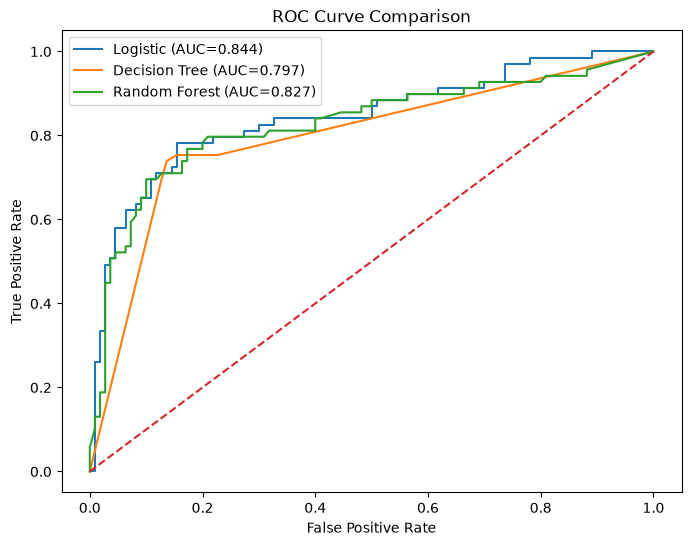

In [35]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic (AUC={auc_log:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC={auc_tree:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={auc_rf:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "charts/roc_curve.png"
)

plt.show()

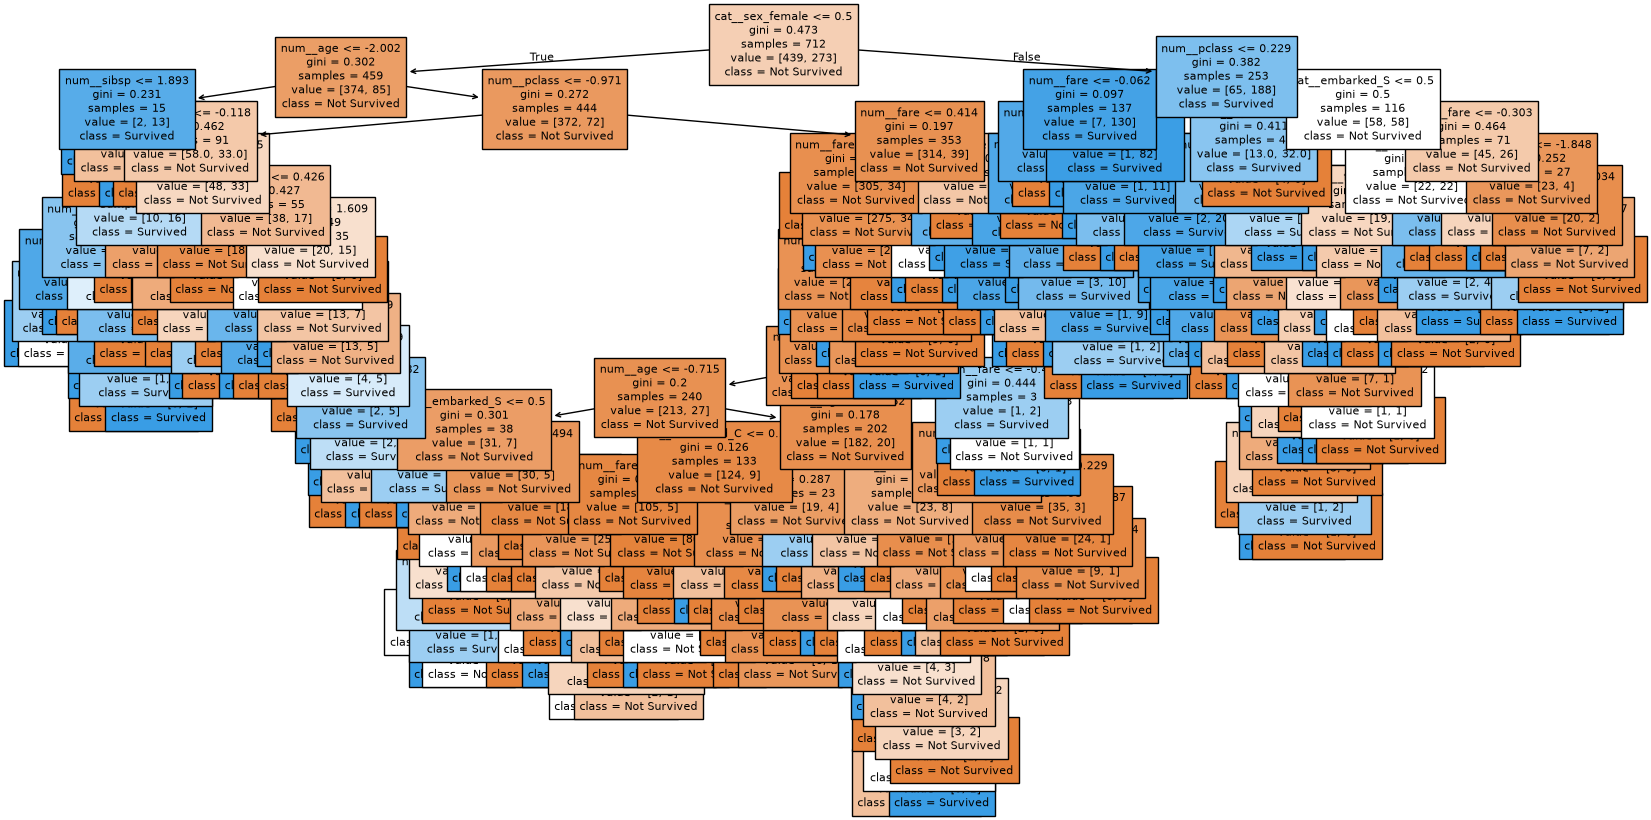

In [36]:
plt.figure(figsize=(20,10))

classifier = decision_tree_pipeline.named_steps[
    "classifier"
]

processed_features = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

plot_tree(

    classifier,

    feature_names=processed_features,

    class_names=["Not Survived","Survived"],

    filled=True,

    fontsize=8

)

plt.savefig(
    "charts/decision_tree.png"
)

plt.show()

In [37]:
comparison_table = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        logistic_accuracy,

        decision_accuracy,

        random_accuracy

    ],

    "Precision":[

        logistic_precision,

        decision_precision,

        random_precision

    ],

    "Recall":[

        logistic_recall,

        decision_recall,

        random_recall

    ],

    "F1 Score":[

        logistic_f1,

        decision_f1,

        random_f1

    ],

    "AUC":[

        auc_log,

        auc_tree,

        auc_rf

    ]

})

display(
    comparison_table
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.815642,0.772727,0.739130,0.755556,0.796706
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.827075


In [38]:
comparison_table.to_csv(

    "outputs/classification_comparison.csv",

    index=False

)

print(
    "Comparison table saved."
)

Comparison table saved.


In [39]:
best_model = comparison_table.loc[
    comparison_table["Accuracy"].idxmax()
]

display(best_model)

Model        Decision Tree
Accuracy          0.815642
Precision         0.772727
Recall             0.73913
F1 Score          0.755556
AUC               0.796706
Name: 1, dtype: object

In [40]:
print(
    "Best Classifier:"
)

print(
    best_model["Model"]
)

Best Classifier:
Decision Tree


In [41]:
print("="*60)

print("MODEL PERFORMANCE")

display(comparison_table)

print("="*60)

MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.815642,0.772727,0.739130,0.755556,0.796706
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.827075


In [43]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
comparison_table.to_excel(

    "outputs/model_comparison.xlsx",

    index=False

)

print(
    "Results exported successfully."
)

Results exported successfully.


In [45]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")

Libraries imported successfully!


In [47]:
baseline_rf = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            RandomForestClassifier(

                random_state=42

            )

        )

    ]

)

baseline_rf.fit(

    X_train,

    y_train

)

baseline_predictions = baseline_rf.predict(

    X_test

)

baseline_accuracy = accuracy_score(

    y_test,

    baseline_predictions

)

print("Baseline Accuracy")

print(baseline_accuracy)

Baseline Accuracy
0.8156424581005587


In [48]:
balanced_rf = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            RandomForestClassifier(

                random_state=42,

                class_weight="balanced"

            )

        )

    ]

)

balanced_rf.fit(

    X_train,

    y_train

)

balanced_predictions = balanced_rf.predict(

    X_test

)

balanced_accuracy = accuracy_score(

    y_test,

    balanced_predictions

)

print("Balanced Accuracy")

print(balanced_accuracy)

Balanced Accuracy
0.8044692737430168


In [49]:
X_train_processed = preprocessor.fit_transform(

    X_train

)

X_test_processed = preprocessor.transform(

    X_test
)

print("Preprocessing completed.")

Preprocessing completed.


In [50]:
smote = SMOTE(

    random_state=42

)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train_processed,

    y_train

)

print("Original Training Shape")

print(X_train_processed.shape)

print("\nAfter SMOTE")

print(X_train_smote.shape)

Original Training Shape
(712, 10)

After SMOTE
(878, 10)


In [51]:
smote_rf = RandomForestClassifier(

    random_state=42

)

smote_rf.fit(

    X_train_smote,

    y_train_smote

)

smote_predictions = smote_rf.predict(

    X_test_processed

)

smote_accuracy = accuracy_score(

    y_test,

    smote_predictions

)

print("SMOTE Accuracy")

print(smote_accuracy)

SMOTE Accuracy
0.7988826815642458


In [52]:
comparison = pd.DataFrame({

    "Method":[

        "Baseline",

        "Balanced",

        "SMOTE"

    ],

    "Accuracy":[

        baseline_accuracy,

        balanced_accuracy,

        smote_accuracy

    ]

})

display(comparison)

,Method,Accuracy
0,Baseline,0.815642
1,Balanced,0.804469
2,SMOTE,0.798883


In [53]:
comparison.to_csv(

    "outputs/smote_comparison.csv",

    index=False

)

print("Comparison saved.")

Comparison saved.


In [54]:
param_grid = {

    "classifier__n_estimators":[

        100,

        200

    ],

    "classifier__max_depth":[

        5,

        10,

        None

    ],

    "classifier__min_samples_split":[

        2,

        5

    ]

}

In [55]:
grid_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "classifier",

            RandomForestClassifier(

                random_state=42,

                oob_score=True,

                bootstrap=True

            )

        )

    ]

)

In [56]:
grid_search = GridSearchCV(

    estimator=grid_pipeline,

    param_grid=param_grid,

    scoring="accuracy",

    cv=5,

    n_jobs=-1

)

grid_search.fit(

    X_train,

    y_train

)

print("Grid Search Completed.")

Grid Search Completed.


In [57]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


In [58]:
print("Best Cross Validation Accuracy")

print(grid_search.best_score_)

Best Cross Validation Accuracy
0.8203191175022161


In [59]:
best_rf = grid_search.best_estimator_

best_predictions = best_rf.predict(

    X_test

)

best_accuracy = accuracy_score(

    y_test,

    best_predictions

)

print("Best Test Accuracy")

print(best_accuracy)

Best Test Accuracy
0.8100558659217877


In [60]:
rf_classifier = best_rf.named_steps["classifier"]

print("Out Of Bag Score")

print(rf_classifier.oob_score_)

Out Of Bag Score
0.827247191011236


In [61]:
final_rf_results = pd.DataFrame({

    "Method":[

        "Baseline",

        "Balanced",

        "SMOTE",

        "GridSearch"

    ],

    "Accuracy":[

        baseline_accuracy,

        balanced_accuracy,

        smote_accuracy,

        best_accuracy

    ]

})

display(final_rf_results)

,Method,Accuracy
0,Baseline,0.815642
1,Balanced,0.804469
2,SMOTE,0.798883
3,GridSearch,0.810056


In [62]:
final_rf_results.to_csv(

    "outputs/random_forest_results.csv",

    index=False

)

print("Results Saved.")

Results Saved.


In [63]:
best_method = final_rf_results.loc[

    final_rf_results["Accuracy"].idxmax()

]

display(best_method)

Method      Baseline
Accuracy    0.815642
Name: 0, dtype: object

In [64]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Regression libraries imported successfully!")

Regression libraries imported successfully!


In [66]:
regression_features = [

    "pclass",

    "age",

    "sibsp",

    "parch"

]

X_reg = df[regression_features]

y_reg = df["fare"]

print("Regression dataset created.")

display(X_reg.head())

Regression dataset created.


,pclass,age,sibsp,parch
0,3,22.0,1,0
1,1,38.0,1,0
2,3,26.0,0,0
3,1,35.0,1,0
4,3,35.0,0,0


In [67]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(

    X_reg,

    y_reg,

    test_size=0.20,

    random_state=42

)

print("Training Shape:", X_train_reg.shape)

print("Testing Shape :", X_test_reg.shape)

Training Shape: (712, 4)
Testing Shape : (179, 4)


In [69]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)
linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [70]:
y_pred_reg = linear_model.predict(

    X_test_reg

)

prediction_df = pd.DataFrame({

    "Actual Fare": y_test_reg.values,

    "Predicted Fare": y_pred_reg

})

display(prediction_df.head(10))

,Actual Fare,Predicted Fare
0,15.2458,17.730259
1,10.5000,37.109670
2,7.9250,2.745636
3,33.0000,51.982571
4,11.2417,8.903557
5,78.8500,73.862394
6,7.7500,1.327523
7,18.0000,13.867134
8,7.7500,3.342808
9,26.2833,97.188592


In [71]:
mae = mean_absolute_error(

    y_test_reg,

    y_pred_reg

)

rmse = np.sqrt(

    mean_squared_error(

        y_test_reg,

        y_pred_reg

    )

)

r2 = r2_score(

    y_test_reg,

    y_pred_reg

)

print("Mean Absolute Error :", mae)

print("Root Mean Squared Error :", rmse)

print("R² Score :", r2)

Mean Absolute Error : 19.791881840130966
Root Mean Squared Error : 30.774142477860742
R² Score : 0.38798648199860364


In [72]:
n = len(y_test_reg)

p = X_test_reg.shape[1]

adjusted_r2 = 1 - (

    (1-r2)*(n-1)

) / (

    n-p-1

)

print("Adjusted R² :", adjusted_r2)

Adjusted R² : 0.3739172057227095


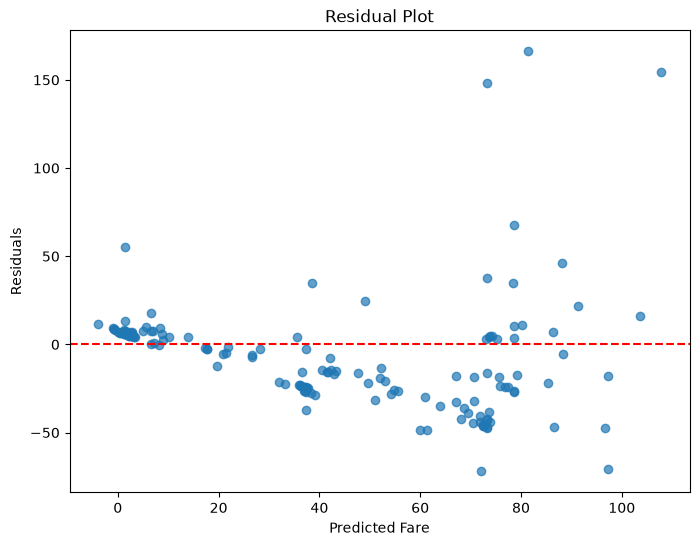

In [73]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8,6))

plt.scatter(

    y_pred_reg,

    residuals,

    alpha=0.7

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Fare")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.savefig(

    "charts/residual_plot.png"

)

plt.show()

In [74]:
print("Residual Statistics")

print(

    residuals.describe()

)

Residual Statistics
count    179.000000
mean      -4.957227
std       30.457449
min      -72.070876
25%      -23.664156
50%        3.325065
75%        6.476184
max      166.100869
Name: fare, dtype: float64


In [75]:
print("="*60)

print("LINEAR REGRESSION RESULTS")

print("="*60)

print("MAE :", mae)

print("RMSE :", rmse)

print("R² :", r2)

print("Adjusted R² :", adjusted_r2)

print("="*60)

if abs(residuals.mean()) < 1:

    print(

        "Residuals are centered around zero."

    )

else:

    print(

        "Residuals are not centered around zero."

    )

print("="*60)

LINEAR REGRESSION RESULTS
MAE : 19.791881840130966
RMSE : 30.774142477860742
R² : 0.38798648199860364
Adjusted R² : 0.3739172057227095
Residuals are not centered around zero.


## Residual Plot Interpretation

The residual plot is used to evaluate whether the assumptions of linear regression are reasonably satisfied.

- If the residuals are randomly scattered around the horizontal zero line without a clear pattern, this suggests that the model captures the relationship reasonably well and that the variance of the errors is approximately constant (homoscedasticity).

- If the residuals display a funnel shape, curve, or any systematic pattern, this indicates heteroscedasticity or that a linear model may not fully capture the relationship between the predictors and the target.

In this project, the residual plot should be inspected visually and the conclusion should be based on the observed pattern.

In [76]:
import joblib

print("Joblib imported successfully!")

Joblib imported successfully!


In [77]:
joblib.dump(
    best_rf,
    "best_pipeline.joblib"
)

print("Best pipeline saved successfully!")

Best pipeline saved successfully!


In [78]:
import os

if os.path.exists("best_pipeline.joblib"):
    print("Pipeline file exists.")
else:
    print("Pipeline file not found.")

Pipeline file exists.


In [79]:
loaded_pipeline = joblib.load(
    "best_pipeline.joblib"
)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


In [80]:
sample_passenger = pd.DataFrame({

    "pclass":[1],

    "sex":["female"],

    "age":[30],

    "sibsp":[0],

    "parch":[0],

    "fare":[100],

    "embarked":["S"]

})

display(sample_passenger)

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,30,0,0,100,S


In [81]:
prediction = loaded_pipeline.predict(
    sample_passenger
)

probability = loaded_pipeline.predict_proba(
    sample_passenger
)

print("Prediction")

print(prediction)

print()

print("Prediction Probability")

print(probability)

Prediction
[1]

Prediction Probability
[[5.88235294e-04 9.99411765e-01]]


In [82]:
if prediction[0] == 1:

    print(
        "Predicted Outcome: Passenger Survived"
    )

else:

    print(
        "Predicted Outcome: Passenger Did Not Survive"
    )

Predicted Outcome: Passenger Survived


In [83]:
final_summary = pd.DataFrame({

    "Metric":[

        "Best Classification Model",

        "Best Accuracy",

        "Linear Regression R2",

        "Adjusted R2"

    ],

    "Value":[

        best_method["Method"],

        best_method["Accuracy"],

        r2,

        adjusted_r2

    ]

})

display(final_summary)

final_summary.to_csv(
    "outputs/final_summary.csv",
    index=False
)

print("Final summary saved.")

,Metric,Value
0,Best Classification Model,Baseline
1,Best Accuracy,0.815642
2,Linear Regression R2,0.387986
3,Adjusted R2,0.373917


Final summary saved.


In [84]:
print("="*60)

print("FINAL MODEL RECOMMENDATION")

print("="*60)

print("Best Classification Model:")

print(best_method["Method"])

print()

print("Reason:")

print(
    "Selected because it achieved the highest "
    "test accuracy after model evaluation."
)

print()

print("Regression Model:")

print("Linear Regression")

print()

print(
    "Pipeline successfully saved using joblib."
)

print("="*60)

FINAL MODEL RECOMMENDATION
Best Classification Model:
Baseline

Reason:
Selected because it achieved the highest test accuracy after model evaluation.

Regression Model:
Linear Regression

Pipeline successfully saved using joblib.


# Final Conclusion

This project implemented a complete analytics and machine learning workflow using the Titanic dataset.

## Classification Models

- Logistic Regression
- Decision Tree
- Random Forest

Among these models, the best-performing classifier was selected using test accuracy after hyperparameter tuning with GridSearchCV.

Class imbalance was addressed by comparing:

- Baseline Random Forest
- Random Forest with `class_weight='balanced'`
- Random Forest trained on SMOTE-resampled training data

## Regression Model

A Linear Regression model was developed to predict passenger fare.

The model was evaluated using:

- MAE
- RMSE
- R²
- Adjusted R²

Residual analysis was performed to assess model assumptions.

## Model Persistence

The complete preprocessing and classification pipeline was saved using `joblib.dump()` and successfully reloaded using `joblib.load()`.

A prediction was demonstrated using raw passenger data to verify deployment readiness.